In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# read the data
data1_0= pd.read_csv('./exp1_0_peak.csv', index_col=0)
print(data1_0.head())
lambda_values1 = data1_0.index.values


data1_50= pd.read_csv('./exp1_50_peak.csv', index_col=0)
lambda_values2 = data1_50.index.values

data1_60= pd.read_csv('./exp1_60_peak.csv', index_col=0)
lambda_values3 = data1_60.index.values

data1_01= pd.read_csv('./exp1_0_peak.csv')
print(data1_01.head())
print(data1_01.index.values)

combined_001 = pd.concat([data1_0['0.01'], data1_50['0.01'], data1_60['0.01']], axis=1, keys=['0', '50', '60'])
combined_50 = pd.concat([data1_0['0.3'], data1_50['0.3'], data1_60['0.3']], axis=1, keys=['0', '50', '60'])
combined_60 = pd.concat([data1_0['0.9'], data1_50['0.9'], data1_60['0.9']], axis=1, keys=['0', '50', '60'])
print(combined_001)


              0.01       0.3       0.9
0.300000  0.504837  0.505461  0.507558
0.305063  0.504152  0.504966  0.506719
0.310125  0.503584  0.504124  0.505927
0.315188  0.502856  0.503398  0.504831
0.320250  0.502002  0.502640  0.504539
   Unnamed: 0      0.01       0.3       0.9
0    0.300000  0.504837  0.505461  0.507558
1    0.305063  0.504152  0.504966  0.506719
2    0.310125  0.503584  0.504124  0.505927
3    0.315188  0.502856  0.503398  0.504831
4    0.320250  0.502002  0.502640  0.504539
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80]
                 0        50        60
0.300000  0.504837  0.521788  0.531716
0.305063  0.504152  0.521119  0.531060
0.310125  0.503584  0.520327  0.530239
0.315188  0.502856  0.520038  0.529964
0.320250  0.502002  0.518694  0.528734
...            ...  

In [ ]:

import pandas as pd

# 定义文件路径与标签
file_info = {
    '0': './exp1_0_peak.csv',
    '50': './exp1_50_peak.csv',
    '60': './exp1_60_peak.csv'
}

# 读取数据
data_dict = {key: pd.read_csv(path, index_col=0) for key, path in file_info.items()}
#print(data_dict.items()) #键值对迭代器

# 提取 lambda 值（假设各文件 index 相同或不冲突）
lambda_values = {key: df.index.values for key, df in data_dict.items()}
print('lambda_values:', lambda_values) # 这是一个dict

# 合并列数据函数
def combine_columns(column_name):
    return pd.concat([df[column_name] for df in data_dict.values()],
                     axis=1, keys=data_dict.keys())

# 合并特定列
combined_001 = combine_columns('0.01')
combined_030 = combine_columns('0.3')
combined_090 = combine_columns('0.9')

# 打印结果示例
print(combined_001.head())
print(combined_001['0'])
print(combined_001.columns)

lambda_values: {'0': array([0.3      , 0.3050625, 0.310125 , 0.3151875, 0.32025  , 0.3253125,
       0.330375 , 0.3354375, 0.3405   , 0.3455625, 0.350625 , 0.3556875,
       0.36075  , 0.3658125, 0.370875 , 0.3759375, 0.381    , 0.3860625,
       0.391125 , 0.3961875, 0.40125  , 0.4063125, 0.411375 , 0.4164375,
       0.4215   , 0.4265625, 0.431625 , 0.4366875, 0.44175  , 0.4468125,
       0.451875 , 0.4569375, 0.462    , 0.4670625, 0.472125 , 0.4771875,
       0.48225  , 0.4873125, 0.492375 , 0.4974375, 0.5025   , 0.5075625,
       0.512625 , 0.5176875, 0.52275  , 0.5278125, 0.532875 , 0.5379375,
       0.543    , 0.5480625, 0.553125 , 0.5581875, 0.56325  , 0.5683125,
       0.573375 , 0.5784375, 0.5835   , 0.5885625, 0.593625 , 0.5986875,
       0.60375  , 0.6088125, 0.613875 , 0.6189375, 0.624    , 0.6290625,
       0.634125 , 0.6391875, 0.64425  , 0.6493125, 0.654375 , 0.6594375,
       0.6645   , 0.6695625, 0.674625 , 0.6796875, 0.68475  , 0.6898125,
       0.694875 , 0.6999375, 0

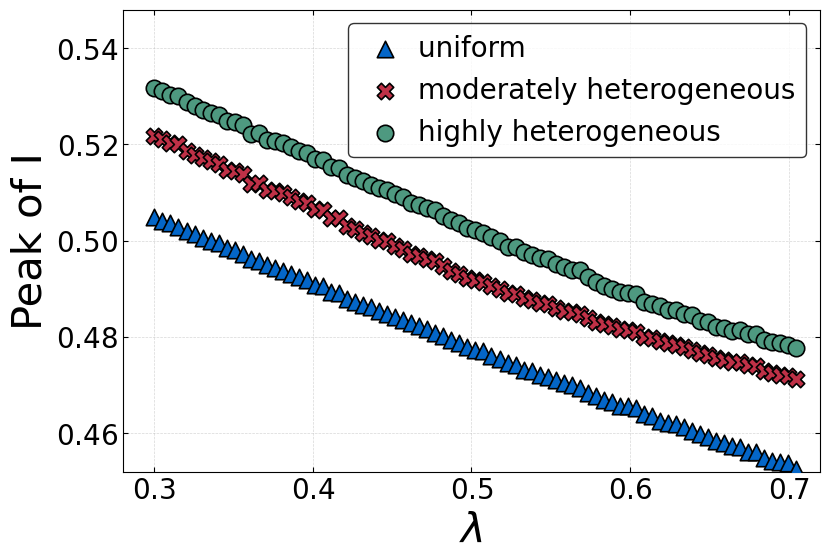

In [54]:
# 绘图

param_combinations = [
    {'population': '0', 'label': f'uniform ', 'color': '#0466c8',   'marker': '^'},
    {'population': '50',  'label': f'moderately heterogeneous',  'color': '#BF3147',   'marker': 'X'},
    {'population': '60',  'label': f'highly heterogeneous ',  'color': '#4E9980',   'marker': 'o'},
]


plt.figure(figsize=(9, 6))

for comb in param_combinations:
    population0 = comb['population']
    label = comb['label']
    
    # print(population0)
    # print(combined_001[population0])
    
    plt.scatter(
        lambda_values[population0],
        combined_001[population0],
        label=label,
        color=comb['color'],
        marker=comb['marker'],
        edgecolors='black',     # 白色填充+黑边
        s=140,                  # 控制点大小
        linewidths=1.2,
        zorder=3
    )

# 图例设置
legend = plt.legend(
    loc='upper right',
    fontsize=20,
    handletextpad=0.3,
    borderpad=0.4,
    handlelength=1.8,
)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1)

# 坐标轴刻度设置
plt.tick_params(
    axis='both',
    which='both',
    top=True,
    right=True,
    labeltop=False,
    labelright=False,
    direction='in',
)

plt.xlabel(r'$\lambda$', fontsize=30)
plt.xticks([0.3, 0.4, 0.5, 0.6, 0.7], [r'$0.3$', r'$0.4$', r'$0.5$', r'$0.6$', r'$0.7$'], fontsize=20)
plt.xlim(0.28, 0.72)

plt.ylabel('Peak of I', fontsize=30)
plt.yticks([0.46, 0.48, 0.5, 0.52, 0.54], [r'$0.46$', r'$0.48$', r'$0.50$', r'$0.52$', r'$0.54$'], fontsize=20)
plt.ylim(0.452, 0.548)

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, zorder=0)

plt.savefig('test5_1.pdf', dpi=300, bbox_inches='tight')
plt.show()


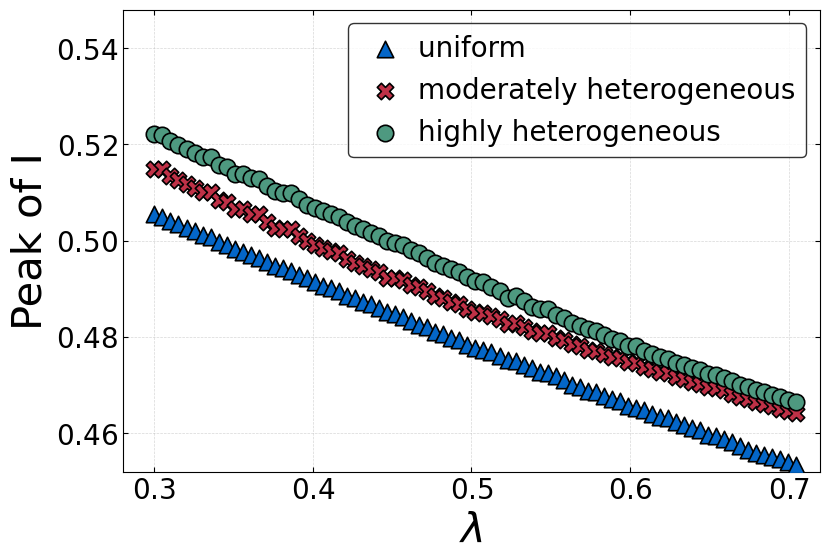

In [55]:
# 绘图

param_combinations = [
    {'population': '0', 'label': f'uniform ', 'color': '#0466c8',   'marker': '^'},
    {'population': '50',  'label': f'moderately heterogeneous',  'color': '#BF3147',   'marker': 'X'},
    {'population': '60',  'label': f'highly heterogeneous ',  'color': '#4E9980',   'marker': 'o'},
]


plt.figure(figsize=(9, 6))

for comb in param_combinations:
    population0 = comb['population']
    label = comb['label']
    
    # print(population0)
    # print(combined_001[population0])
    
    plt.scatter(
        lambda_values[population0],
        combined_030[population0],
        label=label,
        color=comb['color'],
        marker=comb['marker'],
        edgecolors='black',     # 白色填充+黑边
        s=140,                  # 控制点大小
        linewidths=1.2,
        zorder=3
    )

# 图例设置
legend = plt.legend(
    loc='upper right',
    fontsize=20,
    handletextpad=0.3,
    borderpad=0.4,
    handlelength=1.8,
)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1)

# 坐标轴刻度设置
plt.tick_params(
    axis='both',
    which='both',
    top=True,
    right=True,
    labeltop=False,
    labelright=False,
    direction='in',
)

plt.xlabel(r'$\lambda$', fontsize=30)
plt.xticks([0.3, 0.4, 0.5, 0.6, 0.7], [r'$0.3$', r'$0.4$', r'$0.5$', r'$0.6$', r'$0.7$'], fontsize=20)
plt.xlim(0.28, 0.72)

plt.ylabel('Peak of I', fontsize=30)
plt.yticks([0.46, 0.48, 0.5, 0.52, 0.54], [r'$0.46$', r'$0.48$', r'$0.50$', r'$0.52$', r'$0.54$'], fontsize=20)
plt.ylim(0.452, 0.548)

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, zorder=0)

plt.savefig('test5_1.pdf', dpi=300, bbox_inches='tight')
plt.show()


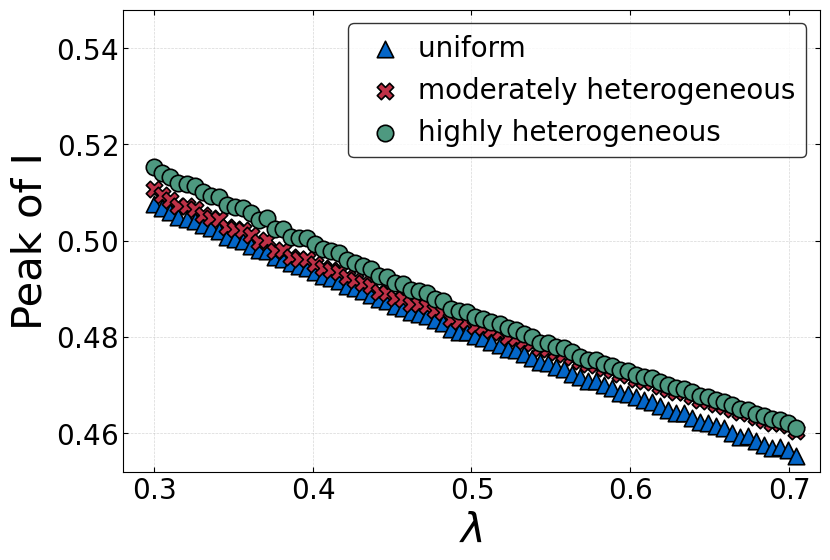

In [56]:
# 绘图

param_combinations = [
    {'population': '0', 'label': f'uniform ', 'color': '#0466c8',   'marker': '^'},
    {'population': '50',  'label': f'moderately heterogeneous',  'color': '#BF3147',   'marker': 'X'},
    {'population': '60',  'label': f'highly heterogeneous ',  'color': '#4E9980',   'marker': 'o'},
]


plt.figure(figsize=(9, 6))

for comb in param_combinations:
    population0 = comb['population']
    label = comb['label']
    
    # print(population0)
    # print(combined_001[population0])
    
    plt.scatter(
        lambda_values[population0],
        combined_090[population0],
        label=label,
        color=comb['color'],
        marker=comb['marker'],
        edgecolors='black',     # 白色填充+黑边
        s=140,                  # 控制点大小
        linewidths=1.2,
        zorder=3
    )

# 图例设置
legend = plt.legend(
    loc='upper right',
    fontsize=20,
    handletextpad=0.3,
    borderpad=0.4,
    handlelength=1.8,
)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1)

# 坐标轴刻度设置
plt.tick_params(
    axis='both',
    which='both',
    top=True,
    right=True,
    labeltop=False,
    labelright=False,
    direction='in',
)

plt.xlabel(r'$\lambda$', fontsize=30)
plt.xticks([0.3, 0.4, 0.5, 0.6, 0.7], [r'$0.3$', r'$0.4$', r'$0.5$', r'$0.6$', r'$0.7$'], fontsize=20)
plt.xlim(0.28, 0.72)

plt.ylabel('Peak of I', fontsize=30)
plt.yticks([0.46, 0.48, 0.5, 0.52, 0.54], [r'$0.46$', r'$0.48$', r'$0.50$', r'$0.52$', r'$0.54$'], fontsize=20)
plt.ylim(0.452, 0.548)

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.5, zorder=0)

plt.savefig('test5_1.pdf', dpi=300, bbox_inches='tight')
plt.show()
